In [12]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [13]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [14]:
simulator = BasicSimulator()
MAX_QUBITS = 24   # hard limit of BasicSimulator

def quantum_random_bits(n: int) -> list:
    """
    Return n random bits by measuring 1/√2(|0⟩+|1⟩) states.
    Requests larger than MAX_QUBITS are split into chunks automatically.
    """
    bits = []
    remaining = n
    while remaining > 0:
        chunk = min(remaining, MAX_QUBITS)
        qc = QuantumCircuit(chunk, chunk)
        for i in range(chunk):
            qc.h(i)                        # |0⟩ → 1/√2(|0⟩ + |1⟩)
        qc.measure(range(chunk), range(chunk))
        job    = simulator.run(transpile(qc, simulator), shots=1)
        bitstr = list(job.result().get_counts().keys())[0]
        bits  += [int(b) for b in reversed(bitstr)]  # little-endian fix
        remaining -= chunk
    return bits[:n]

print(f"Quantum RNG ready (chunk size ≤ {MAX_QUBITS}).")
print("Sample 30 random bits:", quantum_random_bits(30))

Quantum RNG ready (chunk size ≤ 24).
Sample 30 random bits: [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0]


In [15]:
N_QUBITS  = 64    # more qubits → clearer QBER statistics
THRESHOLD = 0.15   # 15% QBER → suspect eavesdropper

print(f"Transmitting {N_QUBITS} qubits | Detection threshold = {THRESHOLD*100:.0f}%")

Transmitting 64 qubits | Detection threshold = 15%


In [11]:
#Alice
alice_bits  = quantum_random_bits(N_QUBITS)
alice_bases = quantum_random_bits(N_QUBITS)

def encode_qubit(bit: int, basis: int) -> QuantumCircuit:
    """
    Z-basis (0): |0⟩ if bit=0, |1⟩ if bit=1
    X-basis (1): |+⟩ if bit=0, |−⟩ if bit=1
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

alice_circuits = [encode_qubit(alice_bits[i], alice_bases[i])
                  for i in range(N_QUBITS)]

print(f"   Alice prepared {N_QUBITS} qubits.")
print(f"   First 10 bits : {alice_bits[:10]}")
print(f"   First 10 bases: {alice_bases[:10]}  (0=Z  1=X)")

   Alice prepared 64 qubits.
   First 10 bits : [0, 1, 0, 1, 1, 1, 0, 0, 0, 0]
   First 10 bases: [0, 0, 1, 0, 0, 1, 0, 1, 1, 1]  (0=Z  1=X)


Identical to the plain version: Alice prepares qubits using quantum-random bit values and bases, encoding them as Z- or X-basis states. Alice is unaware that her qubits will be intercepted.

In [16]:
#eve
eve_bases = quantum_random_bits(N_QUBITS)

def eve_intercept(alice_qc: QuantumCircuit, basis: int):
    """
    Intercept Alice's qubit: measure in Eve's basis, re-encode,
    return (measured_bit, new_circuit_for_bob).
    """
    qc = alice_qc.copy()
    if basis == 1:
        qc.h(0)           # rotate to Z-basis before measuring
    qc.measure(0, 0)
    bit = int(list(simulator.run(transpile(qc, simulator), shots=1)
                             .result().get_counts().keys())[0])
    return bit, encode_qubit(bit, basis)  # re-encode and forward

eve_bits, intercepted = [], []
for i in range(N_QUBITS):
    b, qc = eve_intercept(alice_circuits[i], eve_bases[i])
    eve_bits.append(b)
    intercepted.append(qc)

correct = sum(eve_bases[i] == alice_bases[i] for i in range(N_QUBITS))
print(f"   Eve intercepted all {N_QUBITS} qubits.")
print(f"   Correct basis guesses : {correct} / {N_QUBITS}  ({correct/N_QUBITS*100:.1f}%)  ← expected ~50%")

   Eve intercepted all 64 qubits.
   Correct basis guesses : 37 / 64  (57.8%)  ← expected ~50%


Eve represents the attacker operating between Alice and Bob. She performs an intercept-resend attack: for each qubit, she randomly guesses a measurement basis (using quantum_random_bits()), measures Alice's qubit in that basis, and then re-encodes a fresh qubit with her measured result to forward to Bob. Since Eve guesses the wrong basis ~50% of the time, she randomly collapses the qubit into the wrong state in those cases, introducing errors. This is the key mechanism behind BB84's security — an eavesdropper inevitably disturbs the quantum states she does not know the correct basis for.

In [17]:
#bob
bob_bases = quantum_random_bits(N_QUBITS)

def bob_measure(qc: QuantumCircuit, basis: int) -> int:
    qc2 = qc.copy()
    if basis == 1:
        qc2.h(0)
    qc2.measure(0, 0)
    return int(list(simulator.run(transpile(qc2, simulator), shots=1)
                              .result().get_counts().keys())[0])

bob_results = [bob_measure(intercepted[i], bob_bases[i])
               for i in range(N_QUBITS)]

print(f" Bob measured {N_QUBITS} qubits (unaware they were intercepted).")

 Bob measured 64 qubits (unaware they were intercepted).


Bob receives Eve's re-encoded qubits (not Alice's originals) and measures them with his own random basis, entirely unaware of the interception. When Eve guessed the wrong basis, her re-encoded qubit is in a disturbed state, so even when Alice and Bob's bases match, Bob's result can differ from Alice's — producing detectable errors.

In [18]:
#alice + bob
matching     = [i for i in range(N_QUBITS) if alice_bases[i] == bob_bases[i]]
sifted_alice = [alice_bits[i]  for i in matching]
sifted_bob   = [bob_results[i] for i in matching]

print(f"Total qubits    : {N_QUBITS}")
print(f"Matching bases  : {len(matching)}  ({len(matching)/N_QUBITS*100:.1f}%)")

Total qubits    : 64
Matching bases  : 30  (46.9%)


In [19]:
#eve detected?
half   = len(matching) // 2
errors = sum(sifted_alice[i] != sifted_bob[i] for i in range(half))
qber   = errors / half if half else 0.0

print("─── Security Check ────────────────────────────────────")
print(f"Check bits used : {half}")
print(f"Errors found    : {errors}")
print(f"QBER            : {qber*100:.2f}%")
print(f"Threshold       : {THRESHOLD*100:.0f}%")
print(f"Theoretical QBER (full intercept-resend): 25.00%")

if qber > THRESHOLD:
    print(f"\n ATTACK DETECTED! QBER {qber*100:.2f}% > threshold {THRESHOLD*100:.0f}%")
    print("   ➜ Eve's intercept-resend attack revealed. Protocol aborted.")
else:
    print("\n No attack detected (Eve was unusually lucky — try again).")

─── Security Check ────────────────────────────────────
Check bits used : 15
Errors found    : 3
QBER            : 20.00%
Threshold       : 15%
Theoretical QBER (full intercept-resend): 25.00%

 ATTACK DETECTED! QBER 20.00% > threshold 15%
   ➜ Eve's intercept-resend attack revealed. Protocol aborted.


Alice and Bob compare a sacrificed subset of their sifted key to compute the QBER. Under a full intercept-resend attack, the theoretical error rate is 25% (Eve guesses wrong 50% of the time, and half of those wrong guesses produce an error when Alice and Bob's bases match). Since 25% far exceeds the 15% threshold, the attack is reliably detected and the protocol is aborted. The code prints a clear ATTACK DETECTED message when qber > THRESHOLD.

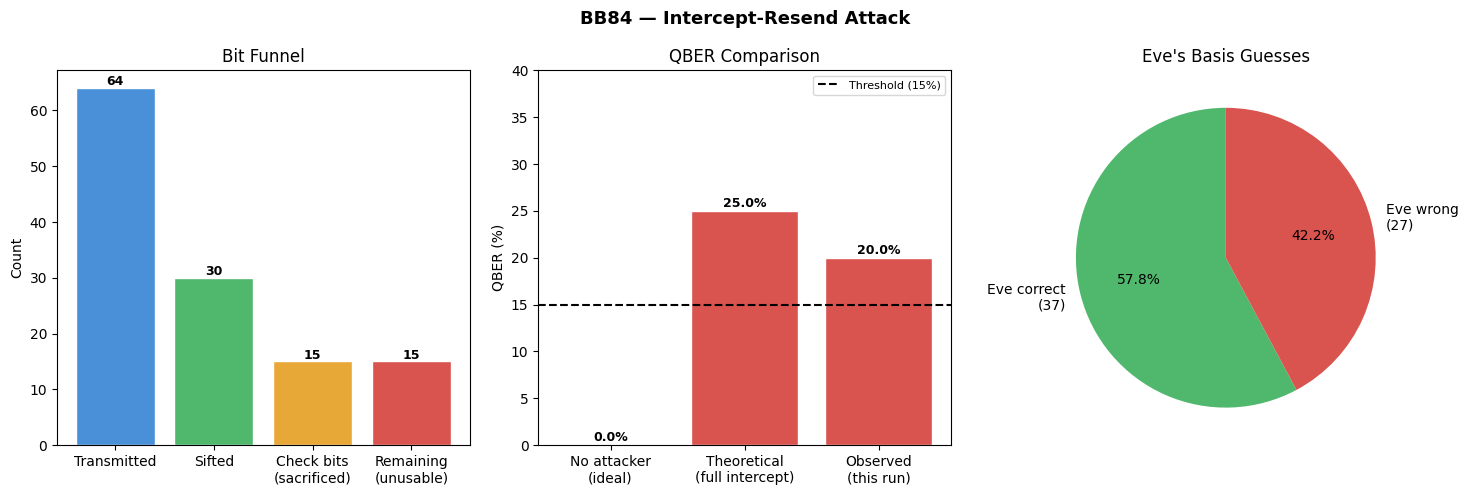


=== Summary ===
Qubits intercepted  : 64 / 64  (100%)
Eve correct guesses : 37 / 64  (57.8%)
Observed QBER       : 20.00%
Attack detected     : YES


In [20]:
#results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("BB84 — Intercept-Resend Attack", fontweight="bold", fontsize=13)

labels = ["Transmitted", "Sifted", "Check bits\n(sacrificed)", "Remaining\n(unusable)"]
vals   = [N_QUBITS, len(matching), half, len(matching) - half]
axes[0].bar(labels, vals, color=["#4a90d9","#50b86c","#e8a838","#d9534f"], edgecolor="white")
axes[0].set_title("Bit Funnel")
axes[0].set_ylabel("Count")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9, fontweight="bold")

qbers = [0.0, 25.0, qber * 100]
xlbls = ["No attacker\n(ideal)", "Theoretical\n(full intercept)", f"Observed\n(this run)"]
cols  = ["#50b86c", "#d9534f", "#e8a838" if qber <= THRESHOLD else "#d9534f"]
axes[1].bar(xlbls, qbers, color=cols, edgecolor="white")
axes[1].axhline(THRESHOLD * 100, color="black", linestyle="--",
                label=f"Threshold ({THRESHOLD*100:.0f}%)")
axes[1].set_ylabel("QBER (%)")
axes[1].set_ylim(0, 40)
axes[1].set_title("QBER Comparison")
axes[1].legend(fontsize=8)
for i, v in enumerate(qbers):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

correct_e   = sum(alice_bases[i] == eve_bases[i] for i in range(N_QUBITS))
incorrect_e = N_QUBITS - correct_e
axes[2].pie(
    [correct_e, incorrect_e],
    labels=[f"Eve correct\n({correct_e})", f"Eve wrong\n({incorrect_e})"],
    colors=["#50b86c", "#d9534f"], autopct="%1.1f%%", startangle=90
)
axes[2].set_title("Eve's Basis Guesses")

plt.tight_layout()
plt.show()

print(f"\n=== Summary ===")
print(f"Qubits intercepted  : {N_QUBITS} / {N_QUBITS}  (100%)")
print(f"Eve correct guesses : {correct_e} / {N_QUBITS}  ({correct_e/N_QUBITS*100:.1f}%)")
print(f"Observed QBER       : {qber*100:.2f}%")
print(f"Attack detected     : {'YES' if qber > THRESHOLD else 'NO'}")

Three plots summarise the attack: the Bit Funnel shows bit reduction through the protocol stages; the QBER Comparison bar chart contrasts the ideal (0%), theoretical (25%), and observed QBER for the current run; and a pie chart shows Eve's basis guess accuracy (~50% correct, as expected from random guessing). These visualisations directly illustrate why the intercept-resend attack is detectable and why BB84 is information-theoretically secure against it.